# Phase 2 — Information Richness Ablation (Leakage-Free)

Ömer Faruk Merey — Middle East Technical University

**Research question.** *How does the semantic richness of auxiliary text captions — ranging from a vision-only baseline, to simple keywords, to detailed qualitative descriptions — impact the accuracy of land cover composition regression from satellite images while strictly avoiding data leakage?*

**Five conditions** (5 × 3 seeds = 15 runs):

| Code | Architecture | Text input |
|---|---|---|
| R0a | CLIP + cross-attn + MLP | `""` (empty token) |
| R0b | CLIP + GAP + MLP | — (no text path) |
| R1  | CLIP + cross-attn + MLP | NER(vision_gemma3 ∪ vision_qwen) keyword string |
| R2a | CLIP + cross-attn + MLP | masked `vision_gemma3-4b` |
| R2b | CLIP + cross-attn + MLP | masked `vision_qwen3-vl-8b` |

Encoders are **frozen**; only fusion + head train.

**M-series Mac note.** CLIP is frozen, so its forward is identical every epoch. We precompute patch + text embeddings once and feed those tensors into training. Same final weights, ~5–10× wall-time speedup vs. running CLIP per batch.


## 1. Setup

In [30]:
%pip uninstall clip -y -q
%pip install -q git+https://github.com/openai/CLIP.git spacy wandb tqdm scipy
%pip install -q --upgrade torch torchvision
!python -m spacy download en_core_web_sm -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [31]:
import sys, os
from pathlib import Path

REPO = Path.cwd().resolve().parents[1]
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
print('repo root:', REPO)

import torch
import clip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src.sanitize import mask_numbers, extract_keywords
from src.dataset import (
    ARASDataset, PrecomputedARASDataset, CONDITIONS, COMPOSITION_CLASSES,
)
from src.precompute import precompute_all
from src.model import build_model
from src.train import TrainConfig, train_one_condition
from src.eval import predict_split, compute_metrics, aggregate_runs, plot_attention

DATASET_DIR = REPO / 'dataset'
IMAGES_DIR = DATASET_DIR / 'images'
CAPTIONS_CSV = DATASET_DIR / 'captions.csv'
CKPT_DIR = REPO / 'checkpoints'; CKPT_DIR.mkdir(exist_ok=True)
PRECOMPUTED_DIR = REPO / 'precomputed'; PRECOMPUTED_DIR.mkdir(exist_ok=True)
REPORTS_DIR = REPO / 'reports' / 'phase-2'; REPORTS_DIR.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print('device:', device)

clip_model, preprocess = clip.load('ViT-B/32', device=device)
clip_model.eval()
tokenizer = clip.tokenize

repo root: /Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition
device: mps


## 2. Sanity checks on sanitization & keyword extraction

In [32]:
demo = 'The image shows grasslands (92%) and crops 2.5% with 6 trees.'
print('original :', demo)
print('masked   :', mask_numbers(demo))

df = pd.read_csv(CAPTIONS_CSV)
row = df.iloc[0]
print('\n--- vision_gemma3-4b ---'); print(row['vision_gemma3-4b'])
print('\n--- vision_qwen3-vl-8b ---'); print(row['vision_qwen3-vl-8b'])
kw = extract_keywords([row['vision_gemma3-4b'], row['vision_qwen3-vl-8b']])
print('\n--- R1 keywords ---'); print(kw)

original : The image shows grasslands (92%) and crops 2.5% with 6 trees.
masked   : The image shows grasslands ([NUM]) and crops [NUM] with [NUM] trees.

--- vision_gemma3-4b ---
This image depicts a rugged, arid landscape characterized by extensive rocky terrain and deeply incised gullies, likely indicative of a desert or semi-arid environment with minimal vegetation cover. The dominant land use appears to be bare rock and soil, shaped by erosion and geological processes.

--- vision_qwen3-vl-8b ---
This remote sensing image shows a rugged, arid landscape dominated by exposed bedrock and sparse vegetation, with a prominent linear feature—likely a dry riverbed or fault line—cutting through the terrain, indicating a geologically active or erosion-prone region.

--- R1 keywords ---
bedrock, cover, desert, environment, feature, image, landscape, line, process, region, riverbed, rock, soil, terrain, use, vegetation


## 3. Inspect a sample for each condition (online dataset)

In [33]:
# Inspect one sample per condition. Rrand is precomputed-only (random tokens),
# so it has no online-mode text to display — skip it here.
for c in CONDITIONS:
    if c == 'Rrand':
        print(f'[{c}] precomputed-only (random CLIP tokens) — see cell 30 for tensors')
        print()
        continue
    ds = ARASDataset(CAPTIONS_CSV, IMAGES_DIR, 'train', c, preprocess, tokenizer,
                     precompute_text=False)
    sample = ds[0]
    txt = sample.get('text', '<no text path>')
    print(f'[{c}] image={tuple(sample["image"].shape)}  gt_sum={sample["gt"].sum():.2f}')
    print(f'      text: {txt[:140]!r}')
    print()

[R0a] image=(3, 224, 224)  gt_sum=1.00
      text: ''

[R0b] image=(3, 224, 224)  gt_sum=1.00
      text: '<no text path>'

[R1] image=(3, 224, 224)  gt_sum=1.00
      text: 'area, dune, image, landscape, moisture, outcrop, patch, pattern, presence, region, river, scene, stream, terrain, that, valley, vegetation, '

[R2a] image=(3, 224, 224)  gt_sum=1.00
      text: 'This image depicts a heavily eroded, arid landscape likely within a desert or semi-arid region, characterized by extensive sand dunes and ro'

[R2b] image=(3, 224, 224)  gt_sum=1.00
      text: 'This remote sensing image shows a semi-arid or arid landscape dominated by dry, brown terrain with sparse vegetation, featuring a distinct, '

[Rrand] precomputed-only (random CLIP tokens) — see cell 30 for tensors



## 4. Precompute frozen CLIP embeddings (one-time, ~3–5 min on M4)

Writes:
- `precomputed/images.pt`            — (10000, 49, 512) fp16
- `precomputed/text_R0a.pt`          — (10000, 77, 512) fp16  (empty captions)
- `precomputed/text_R1.pt`           — (10000, 77, 512) fp16  (NER keywords)
- `precomputed/text_R2a.pt`          — (10000, 77, 512) fp16  (masked vision_gemma)
- `precomputed/text_R2b.pt`          — (10000, 77, 512) fp16  (masked vision_qwen)
- `precomputed/filenames.json`       — ordering check

Total: ~3.7 GB on disk. Re-runs skip already-existing files.

In [34]:
precompute_all(
    CAPTIONS_CSV, IMAGES_DIR, PRECOMPUTED_DIR,
    clip_model, preprocess, tokenizer, device,
    overwrite=False,
)
list(PRECOMPUTED_DIR.iterdir())

[skip] /Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/images.pt exists
[skip] /Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_R0a.pt exists
[skip] /Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_R1.pt exists
[skip] /Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_R2a.pt exists
[skip] /Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_R2b.pt exists


[PosixPath('/Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_R2b.pt'),
 PosixPath('/Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/images.pt'),
 PosixPath('/Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_R1.pt'),
 PosixPath('/Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/filenames.json'),
 PosixPath('/Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_Rrand.pt'),
 PosixPath('/Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_R2a.pt'),
 PosixPath('/Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_R0a.pt')]

## 5. Smoke test (1 epoch, R0a, no W&B) — uses precomputed embeddings

In [35]:
smoke_cfg = TrainConfig(
    condition='R0a', seed=42, epochs=1, batch_size=64,
    use_wandb=False, num_workers=0,
    checkpoint_dir=str(CKPT_DIR / 'smoke'),
    precomputed_dir=str(PRECOMPUTED_DIR),
)
smoke = train_one_condition(
    smoke_cfg, CAPTIONS_CSV, IMAGES_DIR, clip_model, preprocess, tokenizer, device,
)
smoke['history']

[R0a s42] ep00 train=0.04147 val=0.01649 best=0.01649@0 (2.7s)


[{'epoch': 0,
  'train_loss': 0.041470489195414954,
  'val_loss': 0.016486122707525887,
  'lr': 0.0,
  'elapsed_s': 2.661216974258423}]

## 6. Full ablation grid (5 conditions × 3 seeds, precomputed)

Resume-friendly: skips conditions/seeds that already have a checkpoint.

In [36]:
# Reload modules so we pick up the new W&B defaults (di725-project + mereyomerfaruk)
import importlib, src.dataset, src.model, src.train
importlib.reload(src.dataset); importlib.reload(src.model); importlib.reload(src.train)
from src.train import TrainConfig, train_one_condition

USE_WANDB = True
EPOCHS = 30
SEEDS = [42, 1337, 2024]
BATCH_SIZE = 128  # precomputed mode is light enough for big batches

all_results = {}
for cond in CONDITIONS:
    for seed in SEEDS:
        cfg = TrainConfig(
            condition=cond, seed=seed, epochs=EPOCHS, batch_size=BATCH_SIZE,
            use_wandb=USE_WANDB,
            checkpoint_dir=str(CKPT_DIR),
            precomputed_dir=str(PRECOMPUTED_DIR),
        )
        ckpt = CKPT_DIR / f'{cond}_seed{seed}_best.pt'
        if ckpt.exists():
            print(f'-- skipping {cond} seed={seed}: ckpt exists at {ckpt}')
            continue
        print(f'\n=== train {cond} seed={seed} ===')
        all_results[(cond, seed)] = train_one_condition(
            cfg, CAPTIONS_CSV, IMAGES_DIR, clip_model, preprocess, tokenizer, device,
        )


=== train R0a seed=42 ===


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/ofm/.netrc.
wandb: Currently logged in as: mereyomerfaruk (team-lingua) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[R0a s42] ep00 train=0.05322 val=0.04939 best=0.04939@0 (4.5s)
[R0a s42] ep01 train=0.02556 val=0.01605 best=0.01605@1 (3.9s)
[R0a s42] ep02 train=0.01410 val=0.01403 best=0.01403@2 (4.1s)
[R0a s42] ep03 train=0.01290 val=0.01293 best=0.01293@3 (3.7s)
[R0a s42] ep04 train=0.01199 val=0.01245 best=0.01245@4 (3.8s)
[R0a s42] ep05 train=0.01124 val=0.01146 best=0.01146@5 (3.7s)
[R0a s42] ep06 train=0.00982 val=0.00978 best=0.00978@6 (3.7s)
[R0a s42] ep07 train=0.00879 val=0.00902 best=0.00902@7 (3.8s)
[R0a s42] ep08 train=0.00837 val=0.00885 best=0.00885@8 (3.7s)
[R0a s42] ep09 train=0.00785 val=0.00851 best=0.00851@9 (3.7s)
[R0a s42] ep10 train=0.00765 val=0.00849 best=0.00849@10 (3.9s)
[R0a s42] ep11 train=0.00747 val=0.00821 best=0.00821@11 (3.7s)
[R0a s42] ep12 train=0.00725 val=0.00802 best=0.00802@12 (3.8s)
[R0a s42] ep13 train=0.00703 val=0.00827 best=0.00802@12 (3.8s)
[R0a s42] ep14 train=0.00687 val=0.00800 best=0.00800@14 (3.7s)
[R0a s42] ep15 train=0.00682 val=0.00769 best=0.00

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[R0a s42] ep29 train=0.00605 val=0.00736 best=0.00735@27 (3.8s)


...


=== train Rrand seed=2024 ===


[Rrand s2024] ep00 train=0.05459 val=0.05117 best=0.05117@0 (4.6s)
[Rrand s2024] ep01 train=0.04468 val=0.02537 best=0.02537@1 (4.2s)
[Rrand s2024] ep02 train=0.01644 val=0.01472 best=0.01472@2 (4.1s)
[Rrand s2024] ep03 train=0.01306 val=0.01355 best=0.01355@3 (3.9s)
[Rrand s2024] ep04 train=0.01162 val=0.01238 best=0.01238@4 (3.8s)
[Rrand s2024] ep05 train=0.01018 val=0.01099 best=0.01099@5 (3.8s)
[Rrand s2024] ep06 train=0.00887 val=0.01007 best=0.01007@6 (3.8s)
[Rrand s2024] ep07 train=0.00878 val=0.01027 best=0.01007@6 (3.8s)
[Rrand s2024] ep08 train=0.00783 val=0.00951 best=0.00951@8 (3.8s)
[Rrand s2024] ep09 train=0.00738 val=0.00985 best=0.00951@8 (3.8s)
[Rrand s2024] ep10 train=0.00716 val=0.00922 best=0.00922@10 (3.8s)
[Rrand s2024] ep11 train=0.00690 val=0.00915 best=0.00915@11 (3.8s)
[Rrand s2024] ep12 train=0.00675 val=0.00888 best=0.00888@12 (3.8s)
[Rrand s2024] ep13 train=0.00650 val=0.00885 best=0.00885@13 (3.8s)
[Rrand s2024] ep14 train=0.00626 val=0.00876 best=0.00876@

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[Rrand s2024] ep29 train=0.00526 val=0.00840 best=0.00839@26 (3.8s)


elapsed_s,█▅▄▂▂▂▂▁▁▁▁▁▁▁▂▁▁▁▂▁▂▂▁▂▂▂▁▁▁▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
train_loss,█▇▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,26
best_val_loss,0.00839
elapsed_s,3.81574
epoch,29
lr,0
train_loss,0.00526


## 7. Test set evaluation

In [37]:
rows = []
predictions = {}
for cond in CONDITIONS:
    cond_metrics = []
    for seed in SEEDS:
        ckpt = CKPT_DIR / f'{cond}_seed{seed}_best.pt'
        if not ckpt.exists():
            print(f'!! missing ckpt: {ckpt}')
            continue
        out = predict_split(
            cond, seed, CAPTIONS_CSV, IMAGES_DIR,
            clip_model, preprocess, tokenizer, device, ckpt, split='test',
            precomputed_dir=str(PRECOMPUTED_DIR), batch_size=BATCH_SIZE,
        )
        m = compute_metrics(out['pred'], out['gt'])
        m['condition'] = cond; m['seed'] = seed
        cond_metrics.append(m)
        predictions[(cond, seed)] = out
        rows.append(m)
    if cond_metrics:
        agg = aggregate_runs(cond_metrics)
        print(f'{cond}: MSE {agg["mse_mean"]:.5f} ± {agg["mse_std"]:.5f}  '
              f'MAE {agg["mae_mean"]:.5f} ± {agg["mae_std"]:.5f}')

results_df = pd.DataFrame(rows)
results_df.to_csv(REPORTS_DIR / 'phase2_results.csv', index=False)
results_df

R0a: MSE 0.00707 ± 0.00006  MAE 0.04064 ± 0.00029
R0b: MSE 0.01101 ± 0.00032  MAE 0.05541 ± 0.00114
R1: MSE 0.00760 ± 0.00016  MAE 0.04250 ± 0.00083
R2a: MSE 0.00742 ± 0.00011  MAE 0.04189 ± 0.00043
R2b: MSE 0.00739 ± 0.00020  MAE 0.04211 ± 0.00066
Rrand: MSE 0.00787 ± 0.00008  MAE 0.04249 ± 0.00021


,mse,mae,rmse,kl,sum_violation,per_class_mae,per_class_r2,condition,seed
0,0.007120,0.040865,0.084379,0.142066,4.220009e-08,"{'Tree': 0.054602671414613724, 'Shrub': 0.0112...","{'Tree': 0.9265212416648865, 'Shrub': 0.056742...",R0a,42
1,0.007003,0.040307,0.083685,0.138966,4.490217e-08,"{'Tree': 0.05401811748743057, 'Shrub': 0.01155...","{'Tree': 0.9285822510719299, 'Shrub': 0.057141...",R0a,1337
2,0.007076,0.040746,0.084118,0.140751,4.339218e-08,"{'Tree': 0.05505833029747009, 'Shrub': 0.01048...","{'Tree': 0.9264858961105347, 'Shrub': 0.043583...",R0a,2024
3,0.010896,0.054938,0.104382,0.223940,4.172325e-08,"{'Tree': 0.07621664553880692, 'Shrub': 0.00973...","{'Tree': 0.8836901187896729, 'Shrub': -0.01430...",R0b,42
4,0.011373,0.056708,0.106644,0.232697,4.108747e-08,"{'Tree': 0.07767456769943237, 'Shrub': 0.01071...","{'Tree': 0.8801712393760681, 'Shrub': -0.00116...",R0b,1337
5,0.010773,0.054587,0.103793,0.220877,4.335244e-08,"{'Tree': 0.07464098930358887, 'Shrub': 0.01090...","{'Tree': 0.8867006301879883, 'Shrub': -0.00820...",R0b,2024
6,0.007780,0.043456,0.088204,0.155147,4.371007e-08,"{'Tree': 0.05758439749479294, 'Shrub': 0.01199...","{'Tree': 0.921200156211853, 'Shrub': 0.0500273...",R1,42
7,0.007467,0.042049,0.086409,0.150103,4.251798e-08,"{'Tree': 0.0563715361058712, 'Shrub': 0.011195...","{'Tree': 0.9231334328651428, 'Shrub': 0.025364...",R1,1337
8,0.007550,0.042005,0.086893,0.149637,4.367034e-08,"{'Tree': 0.05605200305581093, 'Shrub': 0.01066...","{'Tree': 0.9224888682365417, 'Shrub': 0.026356...",R1,2024
9,0.007409,0.041648,0.086076,0.144466,4.422665e-08,"{'Tree': 0.05628872662782669, 'Shrub': 0.01188...","{'Tree': 0.9238170981407166, 'Shrub': 0.084642...",R2a,42


## 8. Aggregated table & paired significance test

In [38]:
summary = (results_df
           .groupby('condition')[['mse','mae','rmse','kl','sum_violation']]
           .agg(['mean','std']))
summary

mse                 mae                rmse            \
               mean       std      mean       std      mean       std   
condition                                                               
R0a        0.007066  0.000059  0.040639  0.000294  0.084061  0.000350   
R0b        0.011014  0.000317  0.055411  0.001137  0.104940  0.001505   
R1         0.007599  0.000162  0.042504  0.000825  0.087169  0.000929   
R2a        0.007421  0.000107  0.041887  0.000429  0.086144  0.000618   
R2b        0.007388  0.000201  0.042114  0.000661  0.085947  0.001176   
Rrand      0.007874  0.000080  0.042487  0.000209  0.088737  0.000452   

                 kl           sum_violation                
               mean       std          mean           std  
condition                                                  
R0a        0.140594  0.001556  4.349814e-08  1.354151e-09  
R0b        0.225838  0.006134  4.205439e-08  1.168233e-09  
R1         0.151629  0.003055  4.329946e-08  6.770770e-10  
R2a        0.147384  0.003364  4.369683e-08  6.909254e-10  
R2b        0.148363  0.003192  4.290210e-08  4.377009e-10  
Rrand      0.152422  0.001376  4.378955e-08  4.582634e-10

In [39]:
from scipy.stats import ttest_rel

def per_sample_mse(cond):
    arrs = []
    for seed in SEEDS:
        if (cond, seed) not in predictions:
            continue
        o = predictions[(cond, seed)]
        arrs.append(((o['pred'] - o['gt'])**2).mean(axis=-1))
    return np.mean(np.stack(arrs), axis=0) if arrs else None

pairs = [('R0a','R1'), ('R0a','R2a'), ('R0a','R2b'),
         ('R0b','R1'), ('R0b','R2a'), ('R0b','R2b'),
         ('R1','R2a'), ('R1','R2b')]
for a, b in pairs:
    pa, pb = per_sample_mse(a), per_sample_mse(b)
    if pa is None or pb is None:
        continue
    t, p = ttest_rel(pa, pb)
    print(f'{a:>4s} vs {b:<4s}  t={t:+.3f}  p={p:.4g}  '
          f'(mean diff = {pa.mean()-pb.mean():+.5f})')

 R0a vs R1    t=-4.405  p=1.134e-05  (mean diff = -0.00053)
 R0a vs R2a   t=-2.492  p=0.01283  (mean diff = -0.00035)
 R0a vs R2b   t=-2.320  p=0.02049  (mean diff = -0.00032)
 R0b vs R1    t=+10.643  p=1.49e-25  (mean diff = +0.00341)
 R0b vs R2a   t=+10.549  p=3.803e-25  (mean diff = +0.00359)
 R0b vs R2b   t=+11.159  p=7.786e-28  (mean diff = +0.00363)
  R1 vs R2a   t=+1.357  p=0.1751  (mean diff = +0.00018)
  R1 vs R2b   t=+1.475  p=0.1405  (mean diff = +0.00021)


## 9. Bar chart with error bars

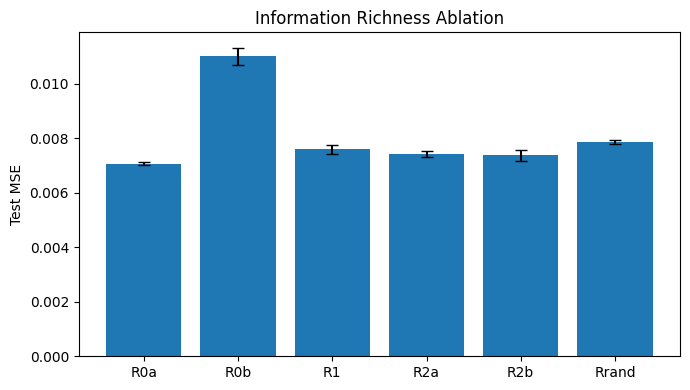

In [40]:
means = summary['mse']['mean']; stds = summary['mse']['std']
order = [c for c in CONDITIONS if c in means.index]

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(order, [means[c] for c in order], yerr=[stds[c] for c in order], capsize=4)
ax.set_ylabel('Test MSE'); ax.set_title('Information Richness Ablation')
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'phase2_mse_bar.png', dpi=150)
plt.show()

## 10. Cross-attention visualisation (R2a, online forward for raw images)

For viz only we re-run CLIP on the few sample images (precomputed mode discards intermediate attention).

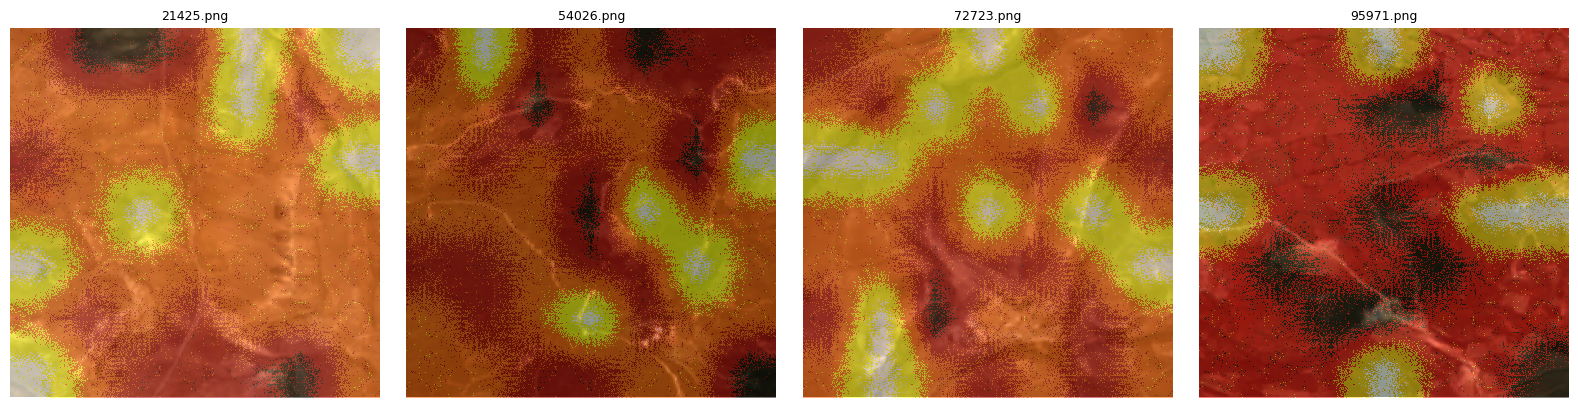

In [41]:
ckpt = CKPT_DIR / 'R2a_seed42_best.pt'
if ckpt.exists():
    model = build_model('R2a', clip_model).to(device)
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state['state_dict'], strict=False)
    model.eval()

    test_ds = ARASDataset(CAPTIONS_CSV, IMAGES_DIR, 'test', 'R2a',
                          preprocess, tokenizer, precompute_text=False)
    fig, axes = plt.subplots(1, 4, figsize=(16,4))
    for k, idx in enumerate(np.linspace(0, len(test_ds)-1, 4, dtype=int)):
        sample = test_ds[idx]
        with torch.no_grad():
            pred, attn = model(sample['image'].unsqueeze(0).to(device),
                                sample['tokens'].unsqueeze(0).to(device),
                                return_attention=True)
        img = Image.open(IMAGES_DIR / sample['filename']).convert('RGB').resize((224,224))
        plot_attention(img, attn.cpu().numpy(), ax=axes[k])
        axes[k].set_title(sample['filename'], fontsize=9)
    plt.tight_layout(); plt.savefig(REPORTS_DIR / 'phase2_attention.png', dpi=150)
    plt.show()
else:
    print('R2a checkpoint not found yet — run the training grid first.')

## 11. Caption-Fidelity Stratified Test (B)

Tests Discussion hypothesis (a): when the vision caption correctly describes the dominant GT class, does conditioning on it help? When it doesn't, does it hurt?

For each test tile we tag it `agree` if at least one synonym of the dominant GT class appears in the relevant sanitized caption, otherwise `disagree`. Then we evaluate every condition on each subset.


In [42]:
# Force-reload src.sanitize because the kernel cached the older version at cell 3
import importlib, src.sanitize
importlib.reload(src.sanitize)
from src.sanitize import caption_describes_dominant_class, mask_numbers, CLASS_SYNONYMS

# Build per-tile agree/disagree label, separately for each text source
df_full = pd.read_csv(CAPTIONS_CSV)
classes = list(COMPOSITION_CLASSES)

def label_set(caption_col):
    out = {}
    for _, r in df_full.iterrows():
        cap = mask_numbers(r[caption_col])
        gt_vec = [r[c] for c in classes]
        out[r['filename']] = caption_describes_dominant_class(cap, classes, gt_vec)
    return out

agree_gemma = label_set('vision_gemma3-4b')
agree_qwen  = label_set('vision_qwen3-vl-8b')
agree_union = {fn: (agree_gemma[fn] or agree_qwen[fn]) for fn in agree_gemma}

print('agree-rate (gemma):', sum(agree_gemma.values())/len(agree_gemma))
print('agree-rate (qwen) :', sum(agree_qwen.values()) /len(agree_qwen))
print('agree-rate (union):', sum(agree_union.values())/len(agree_union))

# Sanity on Phase 1's pet example: 0073.png is Grass-dominant; both vision_* miss it.
print('\n0073.png:',
      'gemma=', agree_gemma.get('0073.png'),
      'qwen=',  agree_qwen.get('0073.png'),
      '(expected both False)')

agree-rate (gemma): 0.4823
agree-rate (qwen) : 0.4695
agree-rate (union): 0.5238

0073.png: gemma= False qwen= False (expected both False)


In [43]:
# Pick which fidelity label each condition is judged against
COND_LABELS = {'R0a': agree_union, 'R0b': agree_union,
               'R1':  agree_union,
               'R2a': agree_gemma, 'R2b': agree_qwen}

strat_rows = []
for cond in CONDITIONS:
    lbl = COND_LABELS.get(cond, agree_union)
    for seed in SEEDS:
        if (cond, seed) not in predictions: continue
        o = predictions[(cond, seed)]
        per = ((o['pred'] - o['gt'])**2).mean(axis=-1)
        agree_mask = np.array([lbl[fn] for fn in o['filenames']])
        for sub_name, mask in [('agree', agree_mask), ('disagree', ~agree_mask)]:
            if mask.sum() == 0: continue
            strat_rows.append({'condition': cond, 'seed': seed, 'subset': sub_name,
                               'n': int(mask.sum()),
                               'mse': float(per[mask].mean())})

strat_df = pd.DataFrame(strat_rows)
strat_summary = (strat_df.groupby(['condition','subset'])['mse']
                  .agg(['mean','std','count']).reset_index())
strat_summary

,condition,subset,mean,std,count
0,R0a,agree,0.006760,0.000144,3
1,R0a,disagree,0.007395,0.000095,3
2,R0b,agree,0.012189,0.000509,3
3,R0b,disagree,0.009751,0.000113,3
4,R1,agree,0.007394,0.000324,3
5,R1,disagree,0.007819,0.000127,3
6,R2a,agree,0.006560,0.000073,3
7,R2a,disagree,0.008189,0.000171,3
8,R2b,agree,0.006801,0.000143,3
9,R2b,disagree,0.007865,0.000254,3


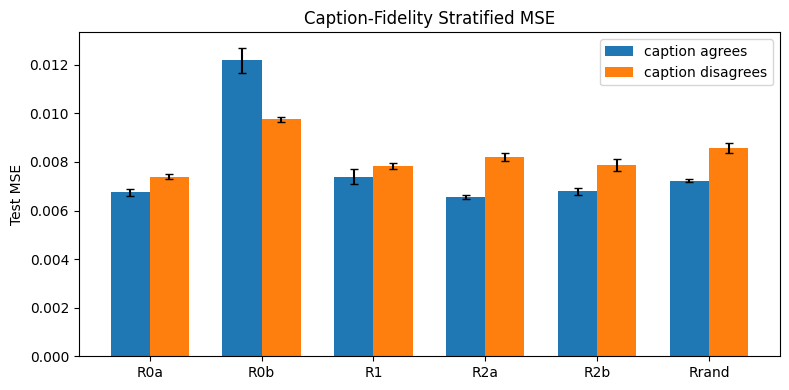

In [44]:
# Bar chart: per condition, agree-MSE vs disagree-MSE
order = [c for c in CONDITIONS if c in strat_summary['condition'].unique()]
agree_m = [strat_summary.query('condition==@c and subset=="agree"')['mean'].iloc[0]    for c in order]
agree_s = [strat_summary.query('condition==@c and subset=="agree"')['std'].iloc[0]     for c in order]
disag_m = [strat_summary.query('condition==@c and subset=="disagree"')['mean'].iloc[0] for c in order]
disag_s = [strat_summary.query('condition==@c and subset=="disagree"')['std'].iloc[0]  for c in order]

x = np.arange(len(order)); w = 0.35
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x-w/2, agree_m, w, yerr=agree_s, capsize=3, label='caption agrees')
ax.bar(x+w/2, disag_m, w, yerr=disag_s, capsize=3, label='caption disagrees')
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel('Test MSE'); ax.set_title('Caption-Fidelity Stratified MSE')
ax.legend()
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'phase2_fidelity_split.png', dpi=150)
plt.show()

## 12. Per-Class MAE Heatmap (C)

Renders the per-class MAE matrix (5 conditions × 7 classes), averaged across seeds. Darker (lower) is better.


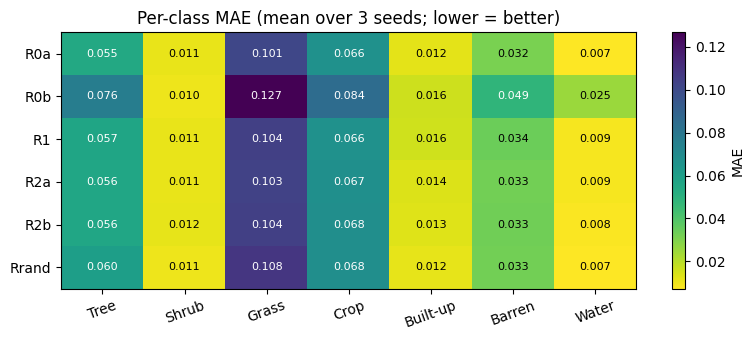

class,Tree,Shrub,Grass,Crop,Built-up,Barren,Water
condition,,,,,,,
R0a,0.054560,0.011101,0.101351,0.066158,0.012432,0.031562,0.007313
R0b,0.076177,0.010452,0.126711,0.084431,0.016349,0.048511,0.025244
R1,0.056669,0.011285,0.104199,0.066480,0.015912,0.034189,0.008791
R2a,0.056076,0.011390,0.103290,0.067182,0.013791,0.032587,0.008891
R2b,0.056216,0.011790,0.104235,0.067912,0.013256,0.033286,0.008104
Rrand,0.059762,0.010518,0.107882,0.067534,0.011656,0.032693,0.007364


In [45]:
import ast
# results_df['per_class_mae'] is stored as a stringified dict in the CSV; parse if needed
def _parse(v):
    return v if isinstance(v, dict) else ast.literal_eval(v)

per_class_long = []
for _, row in results_df.iterrows():
    d = _parse(row['per_class_mae'])
    for cls, val in d.items():
        per_class_long.append({'condition': row['condition'], 'class': cls, 'mae': val})
pcm = (pd.DataFrame(per_class_long)
         .groupby(['condition','class'])['mae'].mean()
         .unstack('class'))
pcm = pcm[list(COMPOSITION_CLASSES)]   # column order
pcm = pcm.loc[[c for c in CONDITIONS if c in pcm.index]]

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(pcm.values, cmap='viridis_r', aspect='auto')
ax.set_xticks(range(len(pcm.columns))); ax.set_xticklabels(pcm.columns, rotation=20)
ax.set_yticks(range(len(pcm.index)));   ax.set_yticklabels(pcm.index)
for i in range(pcm.shape[0]):
    for j in range(pcm.shape[1]):
        ax.text(j, i, f'{pcm.values[i,j]:.3f}', ha='center', va='center',
                color='white' if pcm.values[i,j] > pcm.values.mean() else 'black',
                fontsize=8)
plt.colorbar(im, ax=ax, label='MAE')
ax.set_title('Per-class MAE (mean over 3 seeds; lower = better)')
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'phase2_per_class_heatmap.png', dpi=150)
plt.show()
pcm

## 13. Random-Text Sanity Control (R-rand) — D

Probes Discussion hypothesis (b): is R0a's edge over R0b about cross-attention capacity, or about the empty token actually carrying signal?

R-rand replaces the caption embedding with CLIP's encoding of a fixed sequence of 77 random vocab tokens — same tile, same garbage, every epoch. Identical architecture as R0a/R1/R2.

- |MSE(R-rand) − MSE(R0a)| small → text content is irrelevant; capacity drives the gain.
- MSE(R-rand) >> MSE(R0a) → R0a was extracting something even from the empty token.


In [46]:
# Force-reload src.precompute (and src.dataset which it imports) — kernel cached the pre-Rrand version at cell 3
import importlib, src.dataset, src.precompute
importlib.reload(src.dataset)
importlib.reload(src.precompute)
from src.precompute import precompute_texts

precompute_texts(
    CAPTIONS_CSV, PRECOMPUTED_DIR,
    clip_model, tokenizer, device,
    conditions=('Rrand',), overwrite=False,
)
print(sorted(p.name for p in PRECOMPUTED_DIR.iterdir()))

[skip] /Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_Rrand.pt exists
['filenames.json', 'images.pt', 'text_R0a.pt', 'text_R1.pt', 'text_R2a.pt', 'text_R2b.pt', 'text_Rrand.pt']


In [47]:
# Reload modules that hold cached references to the old (pre-Rrand) src.dataset
import importlib, src.dataset, src.model, src.train
importlib.reload(src.dataset)
importlib.reload(src.model)
importlib.reload(src.train)
from src.train import TrainConfig, train_one_condition

# Train R-rand × 3 seeds (skips if checkpoints exist)
RRAND_RESULTS = {}
for seed in SEEDS:
    cfg = TrainConfig(
        condition='Rrand', seed=seed, epochs=EPOCHS, batch_size=BATCH_SIZE,
        use_wandb=USE_WANDB,
        checkpoint_dir=str(CKPT_DIR),
        precomputed_dir=str(PRECOMPUTED_DIR),
    )
    ckpt = CKPT_DIR / f'Rrand_seed{seed}_best.pt'
    if ckpt.exists():
        print(f'-- skipping Rrand seed={seed}'); continue
    print(f'\n=== train Rrand seed={seed} ===')
    RRAND_RESULTS[seed] = train_one_condition(
        cfg, CAPTIONS_CSV, IMAGES_DIR, clip_model, preprocess, tokenizer, device,
    )

-- skipping Rrand seed=42
-- skipping Rrand seed=1337
-- skipping Rrand seed=2024


In [48]:
# Reload eval (also depends on the new dataset/model)
import importlib, src.dataset, src.model, src.train, src.eval
importlib.reload(src.dataset); importlib.reload(src.model)
importlib.reload(src.train);   importlib.reload(src.eval)
from src.eval import predict_split, compute_metrics, aggregate_runs

# Evaluate R-rand on test, append to results_df
rrand_metrics = []
for seed in SEEDS:
    ckpt = CKPT_DIR / f'Rrand_seed{seed}_best.pt'
    if not ckpt.exists():
        print(f'!! missing ckpt Rrand seed={seed}'); continue
    out = predict_split(
        'Rrand', seed, CAPTIONS_CSV, IMAGES_DIR,
        clip_model, preprocess, tokenizer, device, ckpt, split='test',
        precomputed_dir=str(PRECOMPUTED_DIR), batch_size=BATCH_SIZE,
    )
    m = compute_metrics(out['pred'], out['gt'])
    m['condition'] = 'Rrand'; m['seed'] = seed
    rrand_metrics.append(m); predictions[('Rrand', seed)] = out
    rrand_rows = [r for r in rows if r['condition']=='Rrand' and r['seed']==seed]
    if not rrand_rows:
        rows.append(m)

if rrand_metrics:
    agg = aggregate_runs(rrand_metrics)
    print(f'Rrand: MSE {agg["mse_mean"]:.5f} ± {agg["mse_std"]:.5f}  '
          f'MAE {agg["mae_mean"]:.5f} ± {agg["mae_std"]:.5f}')

# Refresh consolidated table
results_df = pd.DataFrame(rows)
results_df.to_csv(REPORTS_DIR / 'phase2_results.csv', index=False)
summary = (results_df
           .groupby('condition')[['mse','mae','rmse','kl','sum_violation']]
           .agg(['mean','std']))
summary

Rrand: MSE 0.00787 ± 0.00008  MAE 0.04249 ± 0.00021


mse                 mae                rmse            \
               mean       std      mean       std      mean       std   
condition                                                               
R0a        0.007066  0.000059  0.040639  0.000294  0.084061  0.000350   
R0b        0.011014  0.000317  0.055411  0.001137  0.104940  0.001505   
R1         0.007599  0.000162  0.042504  0.000825  0.087169  0.000929   
R2a        0.007421  0.000107  0.041887  0.000429  0.086144  0.000618   
R2b        0.007388  0.000201  0.042114  0.000661  0.085947  0.001176   
Rrand      0.007874  0.000080  0.042487  0.000209  0.088737  0.000452   

                 kl           sum_violation                
               mean       std          mean           std  
condition                                                  
R0a        0.140594  0.001556  4.349814e-08  1.354151e-09  
R0b        0.225838  0.006134  4.205439e-08  1.168233e-09  
R1         0.151629  0.003055  4.329946e-08  6.770770e-10  
R2a        0.147384  0.003364  4.369683e-08  6.909254e-10  
R2b        0.148363  0.003192  4.290210e-08  4.377009e-10  
Rrand      0.152422  0.001376  4.378955e-08  4.582634e-10

In [49]:
# Paired t-test: R0a vs Rrand (the key comparison for hypothesis (b))
from scipy.stats import ttest_rel
def per_sample_mse(cond):
    arrs = []
    for seed in SEEDS:
        if (cond, seed) not in predictions: continue
        o = predictions[(cond, seed)]
        arrs.append(((o['pred'] - o['gt'])**2).mean(axis=-1))
    return np.mean(np.stack(arrs), axis=0) if arrs else None

for a, b in [('R0a','Rrand'), ('R0b','Rrand'), ('R1','Rrand'), ('R2a','Rrand'), ('R2b','Rrand')]:
    pa, pb = per_sample_mse(a), per_sample_mse(b)
    if pa is None or pb is None: continue
    t, p = ttest_rel(pa, pb)
    print(f'{a:>5s} vs {b:<5s}  t={t:+.3f}  p={p:.4g}  '
          f'(mean diff = {pa.mean()-pb.mean():+.5f})')

  R0a vs Rrand  t=-5.790  p=8.579e-09  (mean diff = -0.00081)
  R0b vs Rrand  t=+9.247  p=7.694e-20  (mean diff = +0.00314)
   R1 vs Rrand  t=-1.527  p=0.127  (mean diff = -0.00028)
  R2a vs Rrand  t=-2.313  p=0.02087  (mean diff = -0.00045)
  R2b vs Rrand  t=-2.552  p=0.01082  (mean diff = -0.00049)


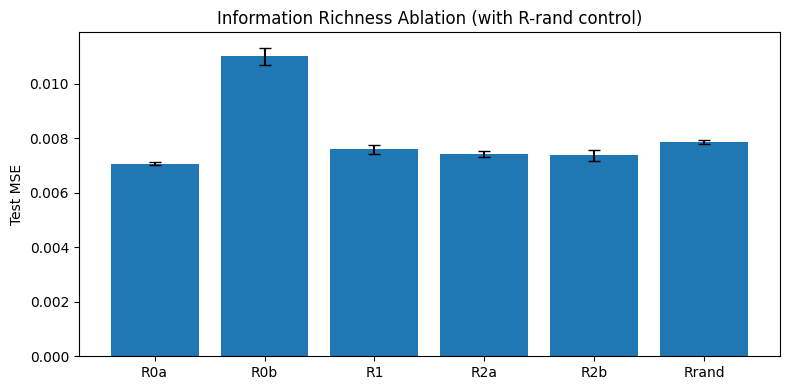

In [50]:
# Updated bar chart with Rrand included
order = [c for c in (*CONDITIONS,) if c in summary['mse']['mean'].index]
means = summary['mse']['mean']; stds = summary['mse']['std']
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(order, [means[c] for c in order], yerr=[stds[c] for c in order], capsize=4)
ax.set_ylabel('Test MSE'); ax.set_title('Information Richness Ablation (with R-rand control)')
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'phase2_mse_bar_with_rrand.png', dpi=150)
plt.show()